# Gold metrics — stop-day & route-day marts

Validates `analysis.metrics.compute_marts` on real silver before the
`gold.py` pipeline runs it nightly. The module folds a `Visit` stream into
two daily marts; this notebook checks the numbers against the raw visits
they summarise, then confirms the rows cast cleanly into the parquet schema.

In [1]:
import datetime as dt
import sys
from pathlib import Path
from zoneinfo import ZoneInfo

import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from analysis import VehicleDay, compute_marts  # noqa: E402
from analysis.metrics import ROUTE_DAY_SCHEMA, STOP_DAY_SCHEMA  # noqa: E402
from gold import load_feed_tz_map  # noqa: E402

FEED = "wmata-vehicles"
DATE = dt.date(2026, 5, 24)
tz = ZoneInfo(load_feed_tz_map(PROJECT_ROOT / "config/feeds.yaml")[FEED])

day = VehicleDay(FEED, DATE, base_dir=PROJECT_ROOT / "curated")
day

VehicleDay(feed='wmata-vehicles', date=2026-05-24)

## Build the marts

Flatten every vehicle's dwells into the `Visit` stream `compute_marts`
consumes, then fold.

In [2]:
visits = [v for veh in day.vehicles for v in veh.dwells]
stop_rows, route_rows = compute_marts(visits, FEED, tz)
print(f"visits     : {len(visits):,}")
print(f"stop-day   : {len(stop_rows):,} rows")
print(f"route-day  : {len(route_rows):,} rows")

stop_df = pd.DataFrame(stop_rows)
stop_df.head()

visits     : 36,260
stop-day   : 647 rows
route-day  : 24 rows


,feed,route_id,direction_id,stop_id,service_date,visit_count,trip_count,distinct_vehicle_count,headway_p50_s,headway_p90_s,headway_mean_s,headway_cov,dwell_p50_s,dwell_p90_s,first_service_unix,last_service_unix,service_span_s
0,wmata-vehicles,SILVER,1,PF_N01_C,2026-05-23,17,14,16,864.0,1105.0,853.125000,0.216625,46,61,1779581085,1779594750,13665
1,wmata-vehicles,SILVER,1,PF_N02_C,2026-05-23,17,14,16,841.0,1102.0,850.500000,0.221221,45,57,1779581219,1779594873,13654
2,wmata-vehicles,SILVER,1,PF_N03_C,2026-05-23,17,14,16,837.0,1116.0,848.562500,0.223562,45,52,1779581374,1779594981,13607
3,wmata-vehicles,SILVER,1,PF_N04_C,2026-05-23,18,15,16,803.0,1117.0,800.176471,0.337018,44,54,1779581501,1779595121,13620
4,wmata-vehicles,SILVER,1,PF_N06_C,2026-05-23,17,14,17,810.0,1140.0,840.875000,0.229711,31,52,1779581085,1779594554,13469


## Sanity vs the raw visits

`visit_count` should sum to the number of dwells with a route (null-route
visits are dropped), and a trip can't be counted more times than it visits.

In [3]:
dwells_with_route = sum(1 for v in visits if v.route_id)
print(f"dwells with route : {dwells_with_route:,}")
print(f"sum(visit_count)  : {stop_df['visit_count'].sum():,}")
assert stop_df["visit_count"].sum() == dwells_with_route
assert (stop_df["trip_count"] <= stop_df["visit_count"]).all()
print("OK")

dwells with route : 36,260
sum(visit_count)  : 36,260
OK


## Headway cross-check

Recompute the busiest (route, dir, stop) headway median by hand and compare
to `headway_p50_s`.

In [4]:
from analysis.event_export import _service_date  # same helper the mart uses

busiest = stop_df.loc[stop_df["visit_count"].idxmax()]
key = (busiest["route_id"], busiest["direction_id"], busiest["stop_id"])
sd = dt.date.fromisoformat(busiest["service_date"])
print("busiest (route, dir, stop):", key, "on", sd)

# Match the mart's bucket exactly — including service_date (a UTC day
# partition can hold two local service dates).
bucket = sorted(
    (
        v
        for v in visits
        if (v.route_id, v.direction_id, v.stop_id) == key
        and _service_date(v.arrival_ts, tz) == sd
    ),
    key=lambda v: v.arrival_ts,
)
hand = [b.arrival_ts - a.arrival_ts for a, b in zip(bucket, bucket[1:])]
print("hand p50 :", int(pd.Series(hand).median()))
print("mart p50 :", busiest["headway_p50_s"])
print("mart cov :", round(busiest["headway_cov"], 3))

busiest (route, dir, stop): ('RED', np.int64(1), 'PF_B11_C') on 2026-05-24
hand p50 : 216
mart p50 : 216.0
mart cov : 3.453


## Headway regularity (CoV) distribution

Regular rail service should cluster at low coefficient of variation.

count    636.000000
mean       1.135881
std        0.913602
min        0.056173
25%        0.237164
50%        0.853112
75%        1.909413
max        3.452749
Name: headway_cov, dtype: float64


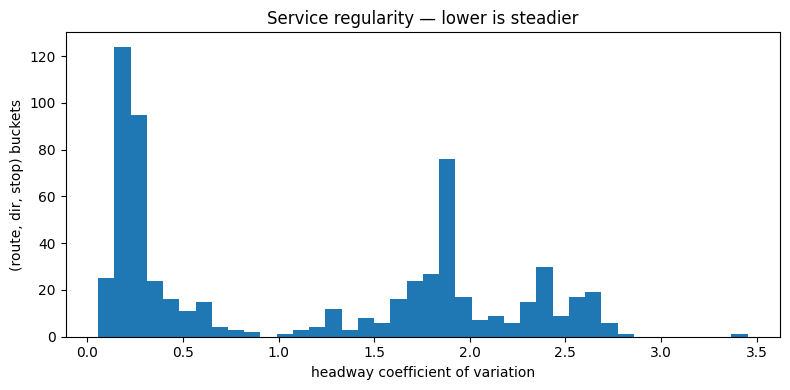

In [5]:
cov = stop_df["headway_cov"].dropna()
print(cov.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cov, bins=40)
ax.set_xlabel("headway coefficient of variation")
ax.set_ylabel("(route, dir, stop) buckets")
ax.set_title("Service regularity — lower is steadier")
plt.tight_layout()
plt.show()

## Null-direction check

Feeds that omit `direction_id` are kept under a null bucket (not dropped).
WMATA publishes direction, so expect ~0 here; a feed run with
`--source trip-updates` that lacks direction would show null rows instead.

In [6]:
null_dir = stop_df["direction_id"].isna().sum()
print(f"null-direction rows: {null_dir} of {len(stop_df)}")

null-direction rows: 0 of 647


## Service-span plausibility

Per-route span in local clock time — a full rail day should run many hours
(short spans flag a partial collection window for that date).

In [7]:
route_df = pd.DataFrame(route_rows)
route_df["first_local"] = route_df["first_service_unix"].map(
    lambda t: dt.datetime.fromtimestamp(t, tz).strftime("%H:%M")
)
route_df["last_local"] = route_df["last_service_unix"].map(
    lambda t: dt.datetime.fromtimestamp(t, tz).strftime("%H:%M")
)
route_df["span_h"] = (route_df["service_span_s"] / 3600).round(1)
route_df[
    [
        "route_id",
        "direction_id",
        "distinct_stop_count",
        "trip_count",
        "headway_p50_s",
        "first_local",
        "last_local",
        "span_h",
    ]
]

,route_id,direction_id,distinct_stop_count,trip_count,headway_p50_s,first_local,last_local,span_h
0,SILVER,1,38,23,860,20:00,00:13,4.2
1,SILVER,0,39,23,821,20:00,00:00,4.0
2,SILVER,1,39,66,738,00:00,19:59,20.0
3,SILVER,0,39,71,728,00:00,19:59,20.0
4,YELLOW,1,22,35,485,20:00,00:00,4.0
5,YELLOW,0,21,37,508,20:00,00:00,4.0
6,YELLOW,1,22,124,481,00:00,19:59,20.0
7,YELLOW,0,22,120,486,00:00,19:59,20.0
8,RED,1,27,37,492,20:00,00:00,4.0
9,RED,0,27,42,434,20:00,00:03,4.1


## Schema round-trip gate

The pre-pipeline check: every value must cast cleanly into the declared
parquet schemas (the extra `feed` key in each row is ignored on write).

In [8]:
stop_tbl = pa.Table.from_pylist(stop_rows, schema=STOP_DAY_SCHEMA)
route_tbl = pa.Table.from_pylist(route_rows, schema=ROUTE_DAY_SCHEMA)
assert stop_tbl.num_rows == len(stop_rows)
assert route_tbl.num_rows == len(route_rows)
print("stop_day  :", stop_tbl.num_rows, "rows cast OK")
print("route_day :", route_tbl.num_rows, "rows cast OK")

stop_day  : 647 rows cast OK
route_day : 24 rows cast OK
